# ODE Models in Julia

In [1]:
using OrdinaryDiffEq, CairoMakie
using Random
using Optim
using ForwardDiff
using ADTypes: AutoForwardDiff
using StableRNGs, QuasiMonteCarlo
using Statistics: mean
using ProgressMeter

## Example model: an Enzyme-catalyzed reaction
In this example, we will model a simple enzyme-catalyzed reaction using ordinary differential equations (ODEs). We have a substrate (S), an enzyme (E), and a product (P). The reactions are as follows:

1. The substrate binds to the enzyme to form a complex (ES).

$ S + E \xrightleftharpoons[k_{-1}]{k_1} ES $

2. The complex then converts to the product and releases the enzyme.

$ ES \xrightarrow{k_2} P + E $

Using mass-action kinetics, we can represent the dynamics of the system with the following ODEs:

\begin{align*}
\frac{d[S]}{dt} &= -k_1 [S][E] + k_{-1} [ES] \\
\frac{d[E]}{dt} &= -k_1 [S][E] + (k_{-1} + k_2) [ES] \\
\frac{d[ES]}{dt} &= k_1 [S][E] - (k_{-1} + k_2) [ES] \\
\frac{d[P]}{dt} &= k_2 [ES]
\end{align*}

We can implement this model in Julia using the `OrdinaryDiffEq` package

We first implement the set of equations as a function with the signature `f(du, u, p, t)`, where `u` is the vector of state variables, `p` is the vector of parameters, and `t` is time. The function will compute the derivatives of the state variables and store them in `du`. 

In [2]:
function enzyme_reaction!(du, u, p, t)
    k1, kn1, k2 = p
    S, E, ES, P = u

    du[1] = -k1 * S * E + kn1 * ES
    du[2] = -k1 * S * E + (kn1 + k2) * ES
    du[3] = k1 * S * E - (kn1 + k2) * ES
    du[4] = k2 * ES
end

enzyme_reaction! (generic function with 1 method)

We now need to specify our initial conditions and parameter values. We can combine those into an ODEProblem.

In [3]:
p = [0.7, 0.5, 0.1] 
u0 = [1.0, 2.0, 0.0, 0.0]  # initial conditions

tspan = (0.0, 20.0)
prob = ODEProblem(enzyme_reaction!, u0, tspan, p)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 20.0)
u0: 4-element Vector{Float64}:
 1.0
 2.0
 0.0
 0.0

Given this ODEProblem, we can simulate the system easily using the `solve` function. This will solve the ODE over the predefined time span, given the initial conditions and parameters. 

We can specify the solver we want to use, but `OrdinaryDiffEq` can also automatically choose a solver for us, which is what happens when we call `solve(prob)` without specifying a solver. Right now, we will specify the solver to be `Tsit5()`, which is a 5th order Runge-Kutta method.

In [4]:
solution = solve(prob, Tsit5(), saveat=0.1);

Julia has several plotting packages available. In this tutorial, we will use `CairoMakie`, which is a very flexible and powerful plotting package. Alternatively, you can use `Plots.jl`, if you want.

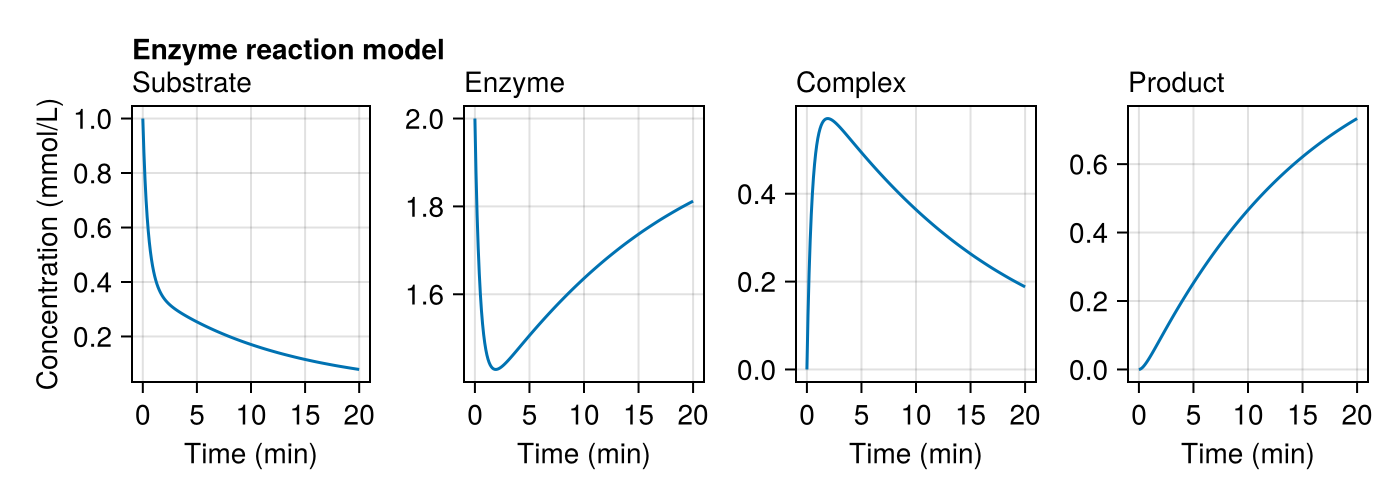

In [5]:
f,ax,l = lines(solution,idxs=1, figure=(size = (700,250),),axis=(
  title="Enzyme reaction model", xlabel="Time (min)", ylabel = "Concentration (mmol/L)",subtitle="Substrate", titlealign=:left)
)
lines(f[1,2],solution,idxs=2, axis=(subtitle="Enzyme", titlealign=:left, xlabel="Time (min)"))
lines(f[1,3],solution,idxs=3, axis=(subtitle="Complex", titlealign=:left, xlabel="Time (min)"))
lines(f[1,4],solution,idxs=4, axis=(subtitle="Product", titlealign=:left, xlabel="Time (min)"))
f

### DIY: Model implementation

We can extend the model to include an inhibitor that binds to the enzyme and prevents it from binding to the substrate. The additional reactions are as follows:

$$ I + E \xrightleftharpoons[k_{-3}]{k_3} EI $$

The associated ODEs for the inhibitor and the inhibitor-enzyme complex are:

\begin{align*}
\frac{d[I]}{dt} &= -k_3 [I] [E] + k_{-3} [EI] \\
\frac{d[EI]}{dt} &= k_3 [I] [E] - k_{-3} [EI]
\end{align*}

And the modified ODE for the enzyme is:

\begin{equation*}
\frac{d[E]}{dt} = -k_1 [S][E] + (k_{-1} + k_2) [ES] - k_3 [I][E] + k_{-3} [EI]
\end{equation*}

**DIY: 1)** Implement the ODEs for the extended model.

**DIY 2)** Simulate the extended model using the same initial conditions and parameter values as before. Choose some random parameters for the inhibitor. Make a figure showing the time evolution of the substrate and product concentrations for the extended model, for different initial concentrations of the inhibitor. Set the initial inhibitor-enzyme complex concentration to zero. You can use the `lines` function to plot the results.

## Local sensitivity analysis
We now have a simulation of the model. In this part, we may want to investigate the local effects of the parameters on the model output. For this reason, we can vary the parameters over a range of values and observe the effect on the model output. This is called local sensitivity analysis. We can do this by simulating the model for different parameter values and plotting the results.

Below you can see an example for parameter $k_1$.

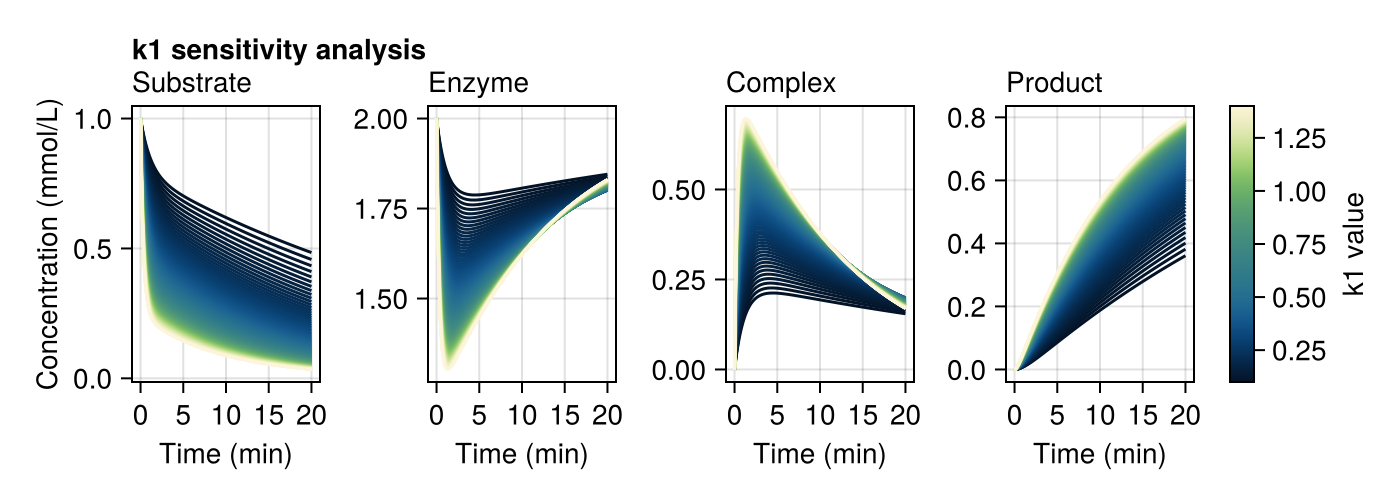

In [6]:
k_1_range = 0.1:0.01:1.4

colorscheme = get(Makie.ColorSchemes.navia, range(0.0, 1.0, length=length(k_1_range)))

figure_k1 = let f = Figure(size=(700,250))
  axs = [
    Axis(f[1,1], title="k1 sensitivity analysis", subtitle="Substrate", titlealign=:left, xlabel="Time (min)", ylabel = "Concentration (mmol/L)"),
    Axis(f[1,2], subtitle="Enzyme", titlealign=:left, xlabel="Time (min)"),
    Axis(f[1,3], subtitle="Complex", titlealign=:left, xlabel="Time (min)"),
    Axis(f[1,4], subtitle="Product", titlealign=:left, xlabel="Time (min)")
  ]

  for (k1,c) in zip(k_1_range, colorscheme)
    p = [k1, 0.5, 0.1]
    prob = ODEProblem(enzyme_reaction!, u0, tspan, p)
    solution = solve(prob, Tsit5(), saveat=0.1)
    lines!(axs[1], solution, idxs=1, color=c)
    lines!(axs[2], solution, idxs=2, color=c)
    lines!(axs[3], solution, idxs=3, color=c)
    lines!(axs[4], solution, idxs=4, color=c)
    
  end
  Colorbar(f[1,5], colormap=Makie.ColorSchemes.navia, limits=(0.1, 1.4), label="k1 value")

  f
end

### DIY: Sensitivity analysis

**DIY 3)** Perform a local sensitivity analysis for the other parameters in the model. Vary each parameter over a range of values and plot the results.

## Parameter Estimation
Typically, we may not know the exact parameter values for the mathematical models that we develop. Usually, measuring parameter values is not directly possible. Instead, we measure model outcomes and tune our model parameters such that the model behaviour matches with whatever we have measured. 

Given a model such as the enzymatic reaction model above, we may be able to measure the concentration of substrate and product at specific timepoints $\mathcal{T}$. Our dataset is then a collection of measurements for the substrate $S_d$ and product $P_d$. When we simulate the model for a random set of initial parameters $\hat{p}$, we can obtain our model simulations for the substrate $S_m$ and $S_p$. 

We can use this to define a typical maximum likelihood optimization problem. Our measurement model looks as follows:

\begin{equation*}
\begin{pmatrix} S_d (t) \\ P_d (t) \end{pmatrix} = \begin{pmatrix} S_m (t) \\ P_m (t) \end{pmatrix} + \Eta
\end{equation*}

Using a multivariate normal error model for our residuals:

\begin{equation*}
\Eta \sim \mathcal{N}\left(\mathbf{0}, \mathbf{\Sigma}\right)
\end{equation*}

Our negative log-likelihood becomes

\begin{equation*}
-\log p(\mathcal{D}|\hat{p}) = \frac{1}{2} \sum_{i=1}^N (\mathbf{y}_i - \mathbf{m}_i(\hat{p}))^\top \mathbf{\Sigma}^{-1} (\mathbf{y}_i - \mathbf{m}_i(\hat{p})) + \frac{N}{2} \log |\mathbf{\Sigma}| + \frac{N}{2} \log 2\pi
\end{equation*}

If we assume that the covariance matrix $\mathbf{\Sigma}$ is diagonal, we can simplify this to

\begin{equation*}
-\log p(\mathcal{D}|\hat{p}) = \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^M \frac{(y_{ij} - m_{ij}(\hat{p}))^2}{\sigma_j^2} + \frac{N}{2} \sum_{j=1}^M \log \sigma_j^2 + \frac{NM}{2} \log 2\pi
\end{equation*}

We can ignore the constant term $\frac{NM}{2} \log 2\pi$ and minimize the negative log-likelihood with respect to the parameters $\hat{p}$ and the variances $\sigma_j^2$.


### Simulating some data
To show how parameter estimation works, we can simulate some data for a given set of model parameters. 

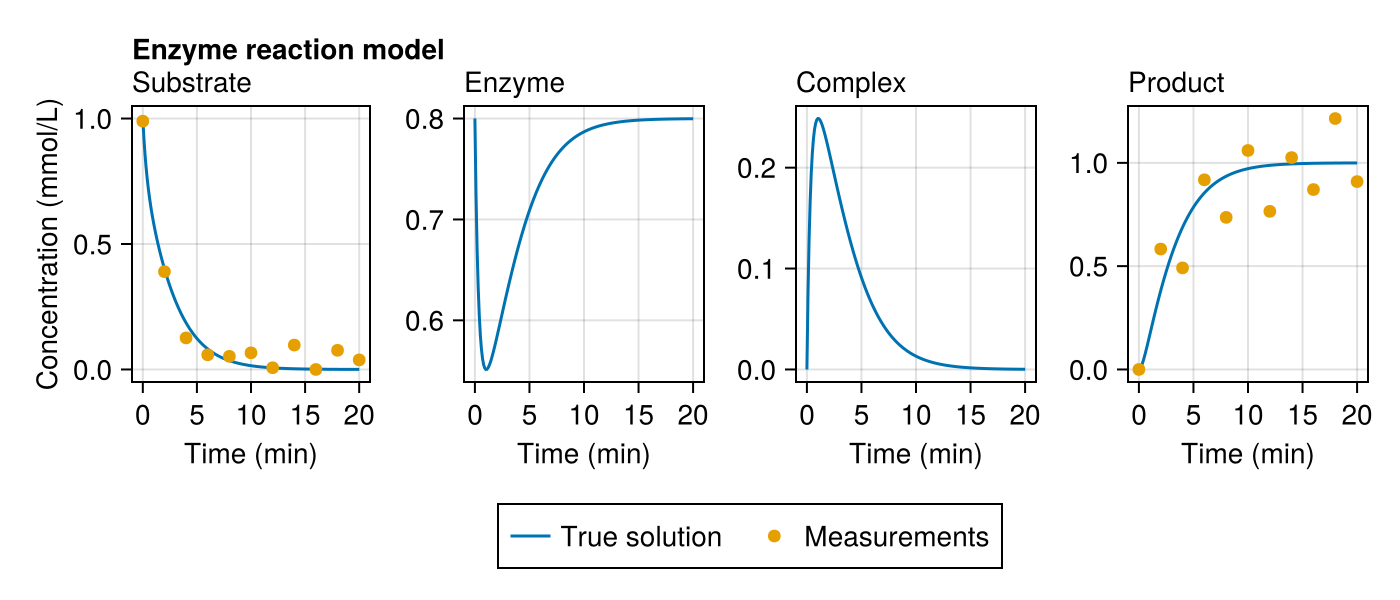

In [7]:
p_true = [1.1, 0.5, 0.9]
sigma_true = [0.05, 0.2]

u0 = [1.0, 8e-1, 0.0, 0.0]
tspan = (0.0,  20.0)
prob = ODEProblem(enzyme_reaction!, u0, tspan, p_true)

solution = solve(prob, Tsit5(), saveat=0.1)
measurements = Array(solve(prob, Tsit5(), saveat = 0:2:20))
# we add noise to simulate a real measurement
measured_S = max.(0.0, measurements[1,:] + randn(size(measurements,2)) .* sigma_true[1])
measured_P = max.(0.0, measurements[4,:] + randn(size(measurements,2)) .* sigma_true[2])

f,ax,l = lines(solution,idxs=1, figure=(size = (700,300),),axis=(
  title="Enzyme reaction model", xlabel="Time (min)", ylabel = "Concentration (mmol/L)",subtitle="Substrate", titlealign=:left)
)
scatter!(ax, 0:2:20, measured_S, color=Makie.wong_colors()[2])
ax2, l = lines(f[1,2],solution,idxs=2, axis=(subtitle="Enzyme", titlealign=:left, xlabel="Time (min)"))
ax3, l = lines(f[1,3],solution,idxs=3, axis=(subtitle="Complex", titlealign=:left, xlabel="Time (min)"))
ax4, l = lines(f[1,4],solution,idxs=4, axis=(subtitle="Product", titlealign=:left, xlabel="Time (min)"), label="True solution")
scatter!(ax4, 0:2:20, measured_P, color=Makie.wong_colors()[2], label="Measurements")
Legend(f[2,1:4], ax4, orientation=:horizontal)
f

### Naive parameter estimation

In [8]:
function negative_log_likelihood(p_est, (prob, substrate, product, timepoints))

  # estimate parameters in log-scale to prevent negative values
  p_est_scaled = exp.(p_est)

  u0 = [substrate[1], 8e-1 , 0.0, product[1]]

  solution = Array(solve(prob, Rodas5P(), p=p_est_scaled[1:3], saveat=timepoints, save_idxs=[1,4]))

  sigma_substrate = p_est_scaled[4]
  sigma_product = p_est_scaled[5]
  nll_substrate = (1/(2 * sigma_substrate^2)) * sum(abs2, substrate - solution[1,:]) + 2*(length(timepoints)/2) * log(sigma_substrate)
  nll_product = (1/(2 * sigma_product^2)) * sum(abs2, product - solution[2,:]) + 2*(length(timepoints)/2) * log(sigma_product)

  return nll_product + nll_substrate
end

negative_log_likelihood (generic function with 1 method)

To be able to automatically compute derivatives of our likelihood function, we need to specify that we will use forward-mode automatic differentiation. This is quite simple.

In [9]:
loss_function = TwiceDifferentiable(
  parameters -> negative_log_likelihood(parameters, (prob, measured_S, measured_P, 0:2:20)),
  ones(5);
  autodiff = AutoForwardDiff()
)

TwiceDifferentiable{Float64, Vector{Float64}, Float64, Matrix{Float64}, Vector{Float64}, Vector{Float64}}(var"#23#24"(), NLSolversBase.var"#37#38"{var"#23#24", DifferentiationInterfaceForwardDiffExt.ForwardDiffGradientPrep{Tuple{var"#23#24", AutoForwardDiff{nothing, Nothing}, Vector{Float64}, Tuple{}}, ForwardDiff.GradientConfig{ForwardDiff.Tag{var"#23#24", Float64}, Float64, 5, Vector{ForwardDiff.Dual{ForwardDiff.Tag{var"#23#24", Float64}, Float64, 5}}}, Tuple{}}, AutoForwardDiff{nothing, Nothing}}(var"#23#24"(), DifferentiationInterfaceForwardDiffExt.ForwardDiffGradientPrep{Tuple{var"#23#24", AutoForwardDiff{nothing, Nothing}, Vector{Float64}, Tuple{}}, ForwardDiff.GradientConfig{ForwardDiff.Tag{var"#23#24", Float64}, Float64, 5, Vector{ForwardDiff.Dual{ForwardDiff.Tag{var"#23#24", Float64}, Float64, 5}}}, Tuple{}}(Val{Tuple{var"#23#24", AutoForwardDiff{nothing, Nothing}, Vector{Float64}, Tuple{}}}(), ForwardDiff.GradientConfig{ForwardDiff.Tag{var"#23#24", Float64}, Float64, 5, Vecto

We can use this to optimize our target function.

In [10]:
lower_bound = ones(5) .* -10.0
upper_bound = ones(5) .* 1.5
constraints = TwiceDifferentiableConstraints(lower_bound, upper_bound)
opt_solution = optimize(loss_function, constraints, ones(5), IPNewton())

 * Status: success

 * Candidate solution
    Final objective value:     -4.417765e+01

 * Found with
    Algorithm:     Interior Point Newton

 * Convergence measures
    |x - x'|               = 0.00e+00 ≤ 0.0e+00
    |x - x'|/|x'|          = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 3.64e-02 ≰ 1.0e-08

 * Work counters
    Seconds run:   4  (vs limit Inf)
    Iterations:    26
    f(x) calls:    73
    ∇f(x) calls:   73
    ∇f(x)ᵀv calls: 0
    ∇²f(x) calls:  26
    ∇²f(x)v calls: 0


Let's inspect our final solution with a plot

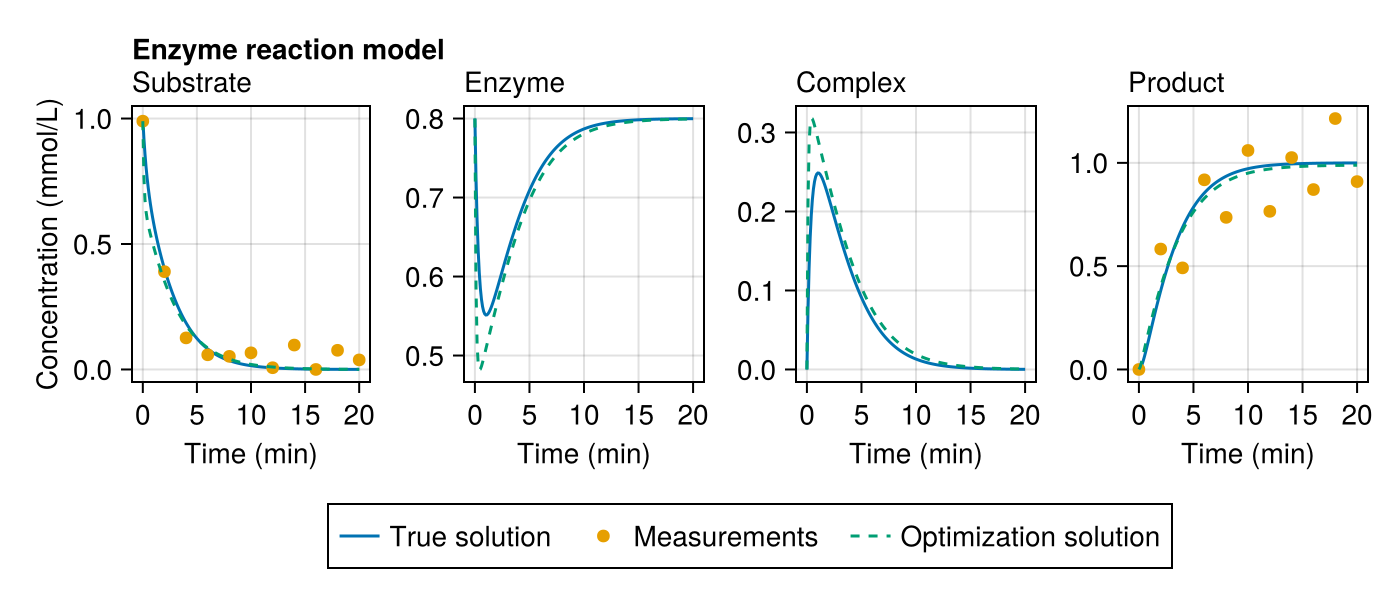

In [11]:

solution = solve(prob, Tsit5(), p=p_true, saveat=0.1)
u0_est = [measured_S[1], 8e-1, 0.0, measured_P[1]]
estimate = solve(prob, Tsit5(), p=exp.(Optim.minimizer(opt_solution))[1:3], u0=u0_est, saveat=0.1)

f,ax,l = lines(solution,idxs=1, figure=(size = (700,300),),axis=(
  title="Enzyme reaction model", xlabel="Time (min)", ylabel = "Concentration (mmol/L)",subtitle="Substrate", titlealign=:left)
)
scatter!(ax, 0:2:20, measured_S, color=Makie.wong_colors()[2])
ax2, l = lines(f[1,2],solution,idxs=2, axis=(subtitle="Enzyme", titlealign=:left, xlabel="Time (min)"))
ax3, l = lines(f[1,3],solution,idxs=3, axis=(subtitle="Complex", titlealign=:left, xlabel="Time (min)"))
ax4, l = lines(f[1,4],solution,idxs=4, axis=(subtitle="Product", titlealign=:left, xlabel="Time (min)"), label="True solution")
scatter!(ax4, 0:2:20, measured_P, color=Makie.wong_colors()[2], label="Measurements")

lines!(ax, estimate, color=Makie.wong_colors()[3], idxs=1, linestyle=:dash)
lines!(ax2, estimate, color=Makie.wong_colors()[3], idxs=2, linestyle=:dash)
lines!(ax3, estimate, color=Makie.wong_colors()[3], idxs=3,  linestyle=:dash)
lines!(ax4, estimate, color=Makie.wong_colors()[3], idxs=4, label="Optimization solution",  linestyle=:dash)

Legend(f[2,1:4], ax4, orientation=:horizontal)
f

We see that we have quite a good fit to our data and the curves are very similar to the true solution. 

### Multi-start optimization
One thing we must note is that this is a _local_ optimization technique, which means that the solution it finds may depend on the initialization of the parameters. To make sure we do not find a better solution if we may have selected different initial conditions, we make use of multi-start optimization. In this technique, we optimize repeatedly from randomly sampled initial conditions, and select the best outcome. 

For sampling random initial conditions, we don't just use a random uniform sampler. Instead, we use Latin Hypercube Sampling. This sampling method ensures that we cover as much of the parameter space with our samples as possible. You can see the difference between random uniform and latin hypercube sampling in the figure we make below:

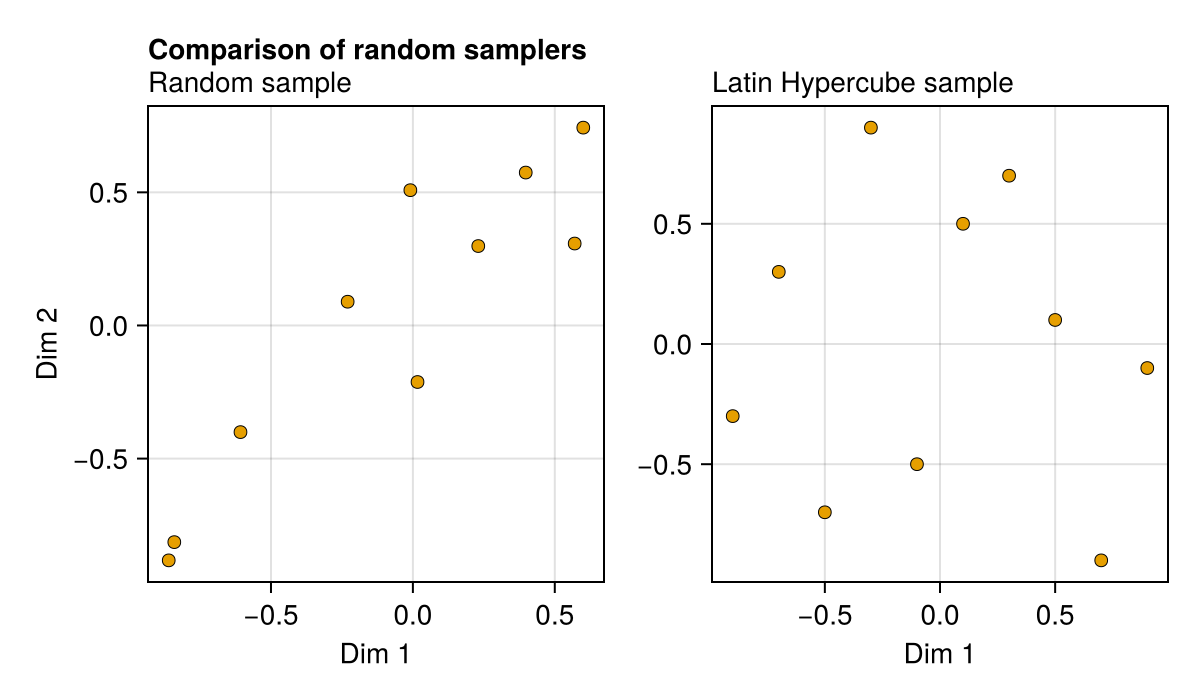

In [17]:
lb = fill(-1.0, 2)
ub = fill(1.0, 2)

rng = StableRNG(1234)

random_samples = rand(rng, 2, 10) .* (ub - lb) .+ lb
lhs_samples = QuasiMonteCarlo.sample(10, lb, ub, LatinHypercubeSample(rng))

figure_lhs = let f = Figure(size=(600,350))

  ax_random = Axis(f[1,1], title="Comparison of random samplers", subtitle="Random sample", xlabel="Dim 1", ylabel="Dim 2", titlealign=:left)
  ax_lhs = Axis(f[1,2], subtitle="Latin Hypercube sample", xlabel="Dim 1", titlealign=:left)
  scatter!(ax_random, random_samples[1,:], random_samples[2,:], color=Makie.wong_colors()[2], strokecolor=:black, strokewidth=0.5)
  scatter!(ax_lhs, lhs_samples[1,:], lhs_samples[2,:], color=Makie.wong_colors()[2], strokecolor=:black, strokewidth=0.5)
  f
end

As you can see, the latin hypercube sampling covers the parameter space much better than random uniform sampling. Now we can use this to perform multi-start optimization. We will use 100 random initial conditions, and optimize from each of them.

In [13]:
lower_bound = ones(5) .* -10.0
upper_bound = ones(5) .* 1.5

initial_points = QuasiMonteCarlo.sample(100, lower_bound, upper_bound, LatinHypercubeSample(rng))
constraints = TwiceDifferentiableConstraints(lower_bound, upper_bound)

results = Vector{Float64}[]
loss_values = Float64[]
@showprogress for x0 in eachcol(initial_points)
  opt_solution = optimize(loss_function, constraints, copy(x0), IPNewton())
  push!(results, Optim.minimizer(opt_solution))
  push!(loss_values, Optim.minimum(opt_solution))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:18


To inspect the solutions, we can use a waterfall plot to see the loss values for each of the optimization runs.

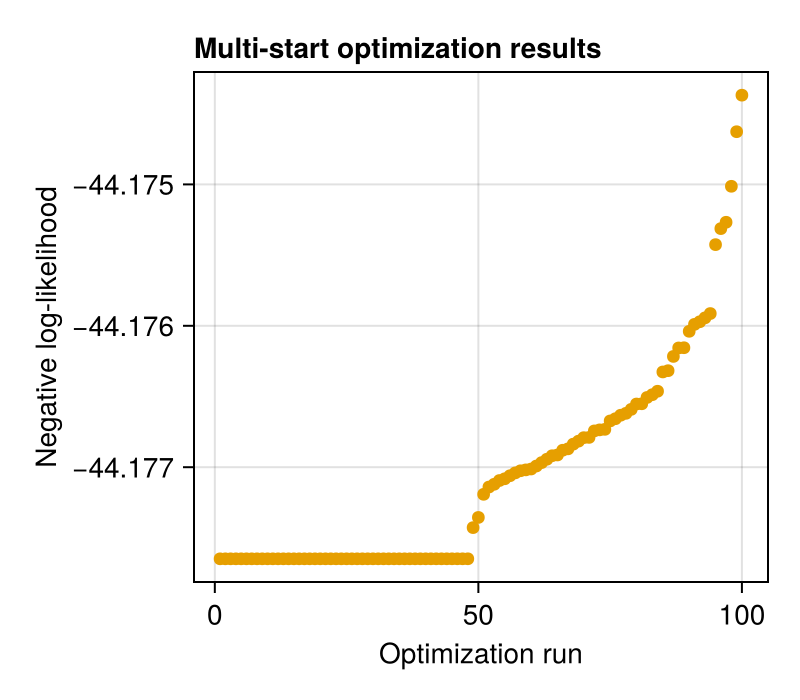

In [14]:
figure_waterfall = let f = Figure(size=(400,350))
  ax = Axis(f[1,1], title="Multi-start optimization results", xlabel="Optimization run", ylabel="Negative log-likelihood", titlealign=:left)
  scatter!(ax, 1:length(loss_values), sort(loss_values), color=Makie.wong_colors()[2])
  f
end

We can see that the loss values are almost all equal, with negligible differences. We will take the best solution and plot the model output for this solution. We can see that the model output is very similar to the true solution, and we have found a good fit to our data. For more complex models and in situations with real data, we may find that the loss values are more spread out, and we may find a better solution if we optimize from different initial conditions.

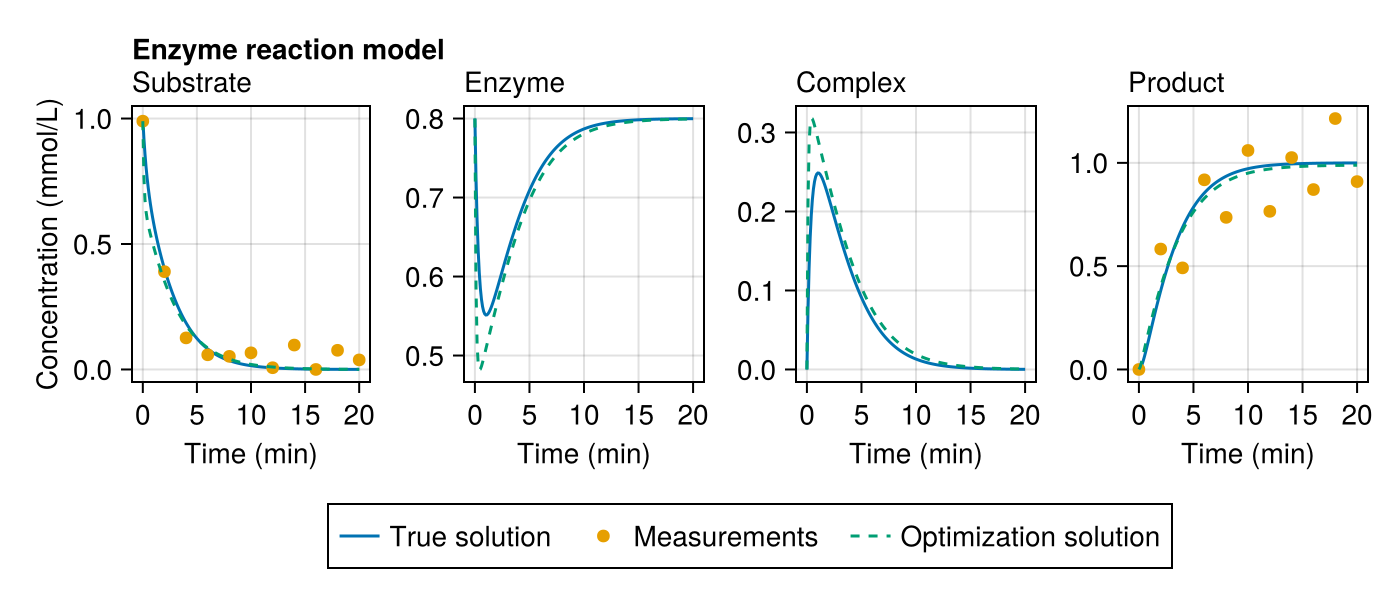

In [15]:
solution = solve(prob, Tsit5(), p=p_true, saveat=0.1)
u0_est = [measured_S[1], 8e-1, 0.0, measured_P[1]]
estimate = solve(prob, Tsit5(), p=exp.(results[argmin(loss_values)])[1:3], u0=u0_est, saveat=0.1)

f,ax,l = lines(solution,idxs=1, figure=(size = (700,300),),axis=(
  title="Enzyme reaction model", xlabel="Time (min)", ylabel = "Concentration (mmol/L)",subtitle="Substrate", titlealign=:left)
)
scatter!(ax, 0:2:20, measured_S, color=Makie.wong_colors()[2])
ax2, l = lines(f[1,2],solution,idxs=2, axis=(subtitle="Enzyme", titlealign=:left, xlabel="Time (min)"))
ax3, l = lines(f[1,3],solution,idxs=3, axis=(subtitle="Complex", titlealign=:left, xlabel="Time (min)"))
ax4, l = lines(f[1,4],solution,idxs=4, axis=(subtitle="Product", titlealign=:left, xlabel="Time (min)"), label="True solution")
scatter!(ax4, 0:2:20, measured_P, color=Makie.wong_colors()[2], label="Measurements")

lines!(ax, estimate, color=Makie.wong_colors()[3], idxs=1, linestyle=:dash)
lines!(ax2, estimate, color=Makie.wong_colors()[3], idxs=2, linestyle=:dash)
lines!(ax3, estimate, color=Makie.wong_colors()[3], idxs=3,  linestyle=:dash)
lines!(ax4, estimate, color=Makie.wong_colors()[3], idxs=4, label="Optimization solution",  linestyle=:dash)

Legend(f[2,1:4], ax4, orientation=:horizontal)
f

### DIY: Parameter estimation

**DIY 4)** Simulate some new data with different noise levels and investigate the effect of the noise on the parameter estimates.  
- What is the effect of noise on the estimated residual variances $\sigma_j^2$? 
- What is the effect of noise on the estimated parameters $\hat{p}$?

**DIY 5)** Right now, we assumed we knew the initial enzyme concentration to be $[E]_0 = 8 \cdot 10^{-1}$. If you have enough data, you could also estimate the initial enzyme concentration as a parameter. You can do this by adding an additional parameter to your optimization problem, and modifying the initial conditions of your ODE problem to use this parameter.

- From the data that we have, can you also estimate the parameters as well as the initial enzyme concentration? Try to implement this below. What do you observe?

## Complicated Parameter Estimation Problems
